In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.special import logsumexp
from matplotlib import gridspec


In [2]:

def crop_by_threshold(A, val, pad=1):
    """
    Returns subarray that contains all entries >= val.
    Everything outside the returned subarray is guaranteed < val.

    pad: optional extra margin (in pixels) to keep around the box.
    """
    A = np.asarray(A)
    mask = A >= val

    if A.ndim != 2:
        cols = np.where(mask)[0]
        return cols[0], cols[-1]

    if mask.all():
        return (0, A.shape[0] - 1, 0, A.shape[1] - 1)

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]

    # optional padding, clipped to bounds
    r0 = max(0, r0 - pad)
    c0 = max(0, c0 - pad)
    r1 = min(A.shape[0] - 1, r1 + pad)
    c1 = min(A.shape[1] - 1, c1 + pad)

    return r0, r1, c0, c1


/tmp/ipykernel_391124/1459729173.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_391124/1459729173.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_391124/1459729173.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_391124/1459729173.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_391124/1459729173.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_391124/1459729173.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so

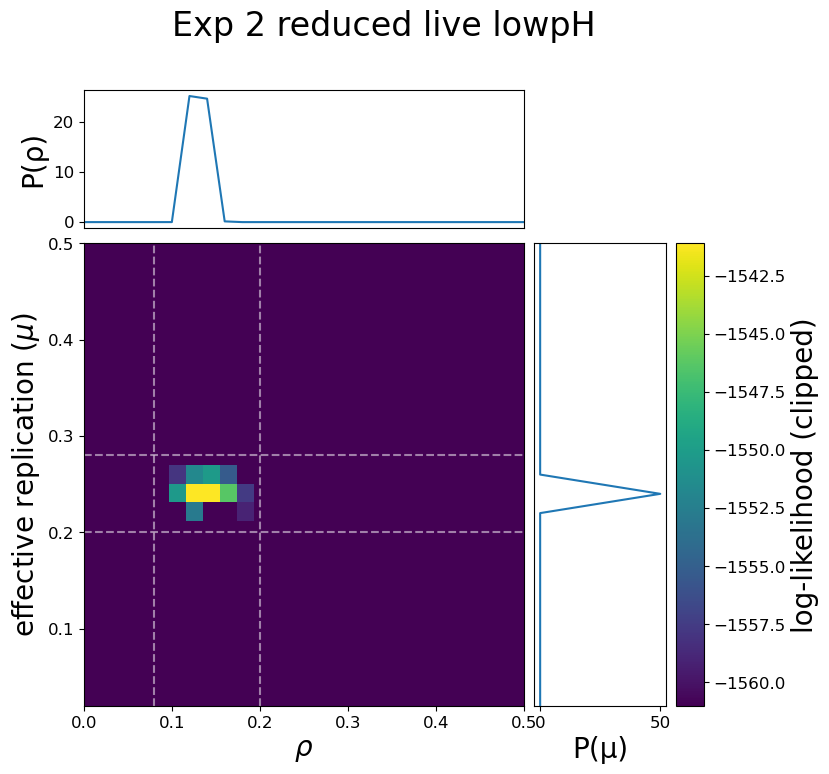

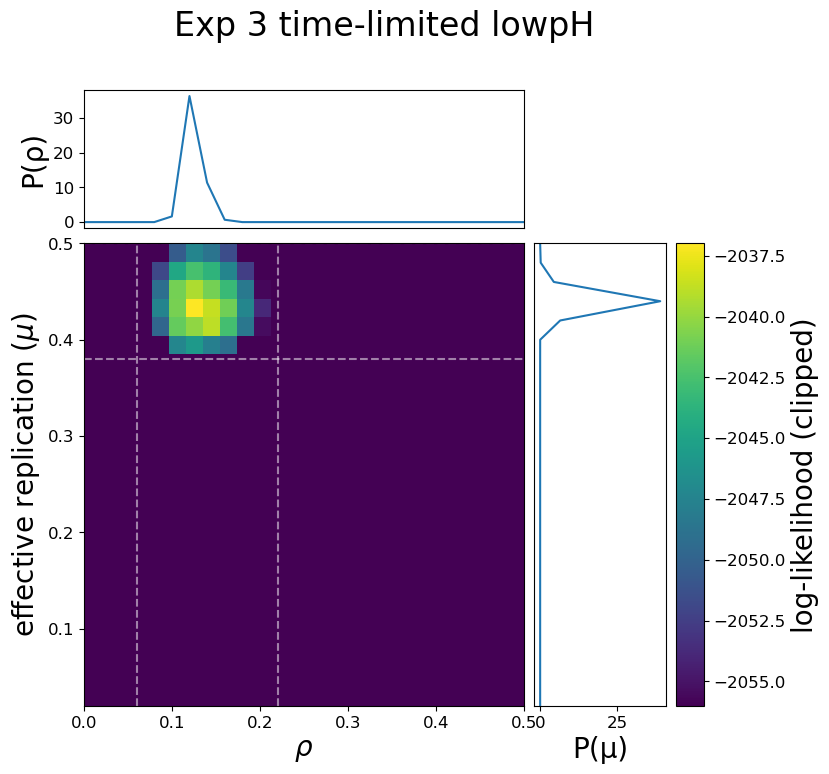

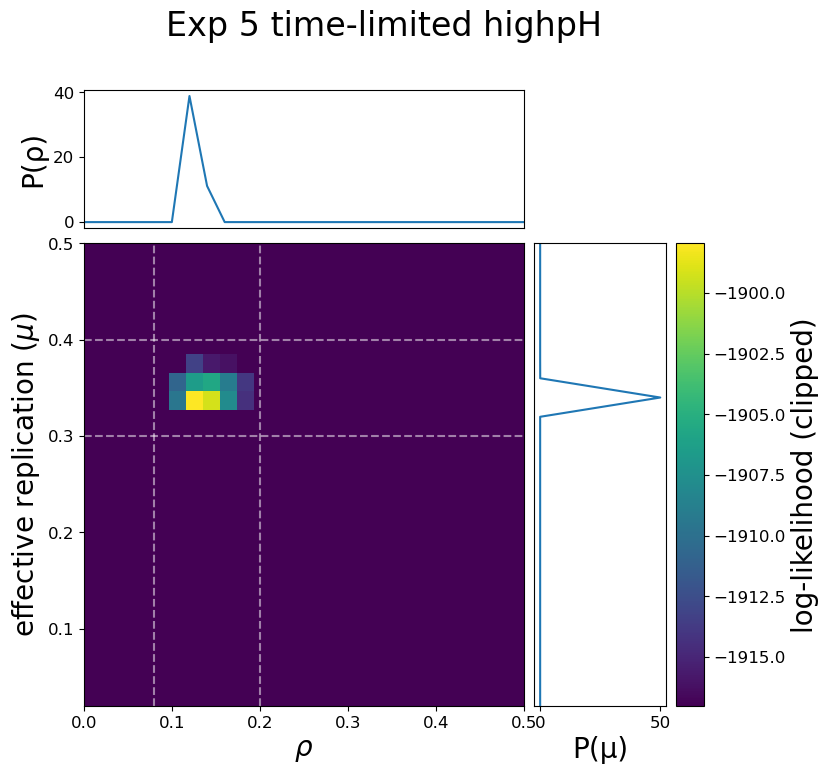

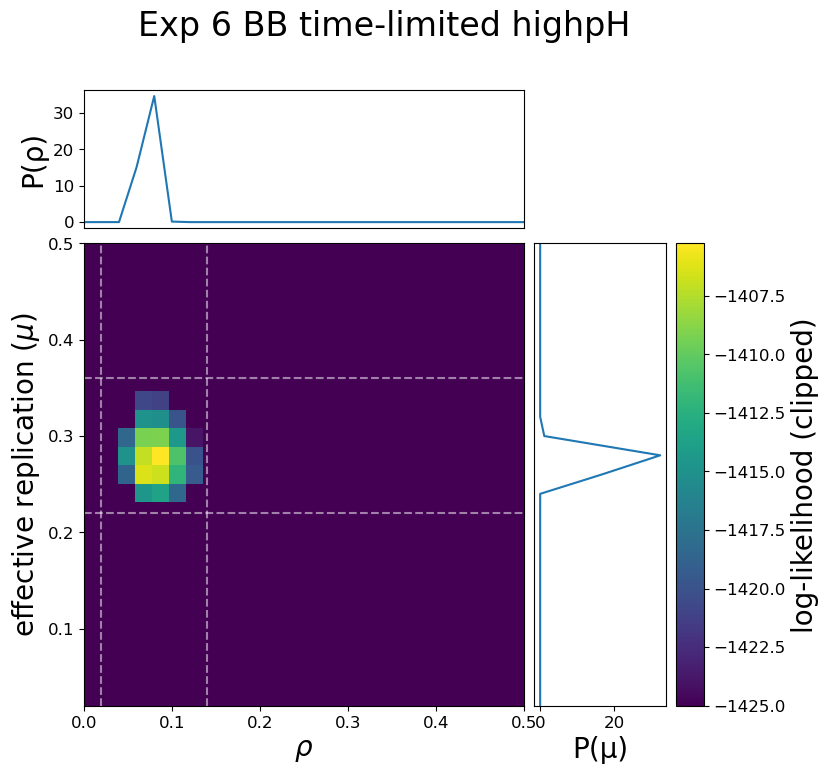

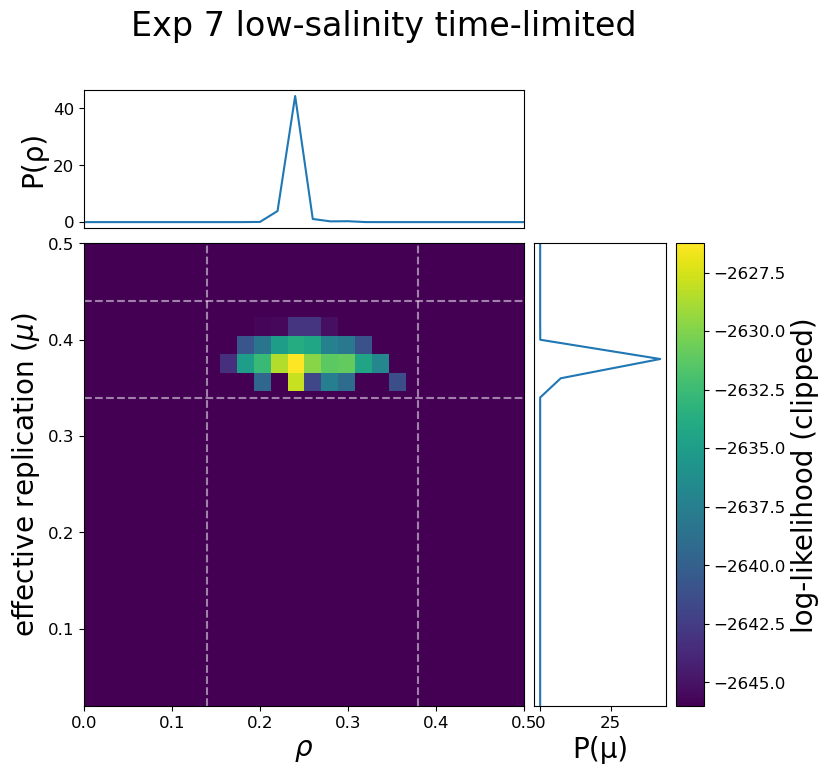

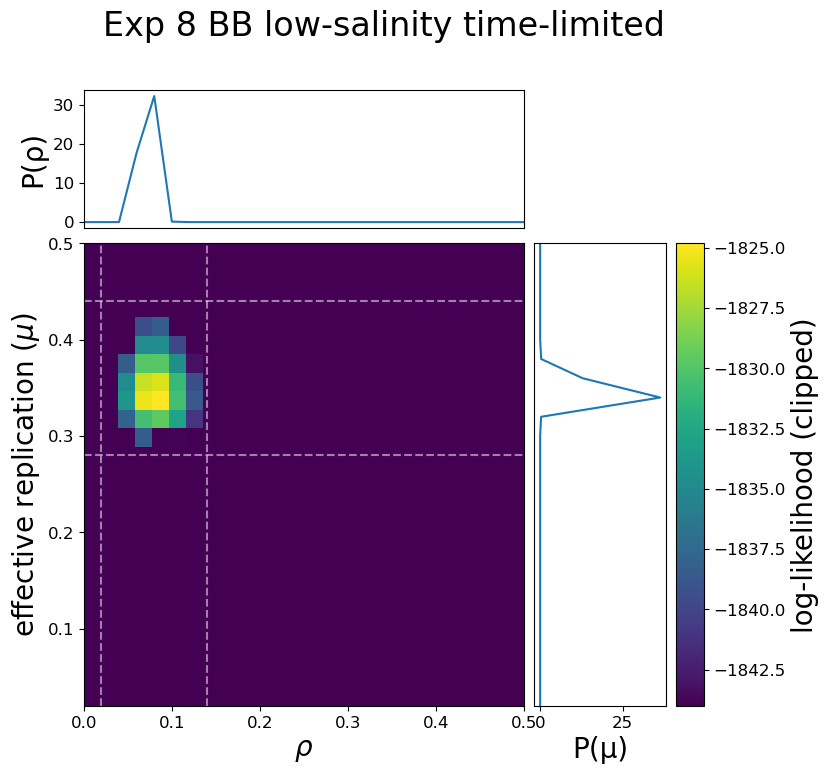

In [3]:

titles = ['Exp_2_reduced_live_lowpH', 'Exp_3_time-limited_lowpH', 'Exp_5_time-limited_highpH', 'Exp_6_BB_time-limited_highpH', 'Exp_7_low-salinity_time-limited', 'Exp_8_BB_low-salinity_time-limited']

#titles = [ 'Exp_3_time-limited_lowpH', 'Exp_5_time-limited_highpH', 'Exp_6_BB_time-limited_highpH', 'Exp_7_low-salinity_time-limited', 'Exp_8_BB_low-salinity_time-limited']

results = []


for title in titles:
    input = f"grid_likelihood_outputs/{title}/grid_zomega.csv"
    output = f"grid_likelihood_outputs/{title}/grid_zomega.png"

    df = pd.read_csv(input)
    df = df[df["mu"]<=.5]
    df = df[df["rho"]<=.5]

    rhos = np.unique(df["rho"].values)
    mus = np.unique(df["mu"].values)

    sh = (mus.size, rhos.size)
    A = df["rho"].values.reshape(sh)
    M = df["mu"].values.reshape(sh)
    Z = df["loglike"].values.reshape(sh)

    Zeff = Z.clip(min = int(np.max(Z)-20))  # normalize to get log-probabilities
    Z_rho = logsumexp(Z, axis=0) - logsumexp(Z)
    Z_mu = logsumexp(Z, axis=1) - logsumexp(Z)

    r0, r1, c0, c1 = crop_by_threshold(Z, Zeff.min())

    results.append({
        "title": title,
        "mu_low": mus[r0],
        "mu_high": mus[r1], 
        "rho_low": rhos[c0],
        "rho_high": rhos[c1],
    })

    plt.rcParams.update({
        "font.size": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 20
    })

    P_rho = np.exp(Z_rho - np.log(rhos[1] - rhos[0]))
    P_mu    = np.exp(Z_mu - np.log(mus[1] - mus[0]))
    # --- layout ---


    # --- layout with dedicated colorbar column ---
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(
        2, 3,
        width_ratios=[4, 1.2, 0.25],   # extra column for colorbar
        height_ratios=[1.2, 4],
        hspace=0.05,
        wspace=0.05
    )

    ax_top    = fig.add_subplot(gs[0, 0])
    ax_joint  = fig.add_subplot(gs[1, 0])
    ax_right  = fig.add_subplot(gs[1, 1])
    ax_cbar   = fig.add_subplot(gs[1, 2])  # colorbar axis

    # --- joint heatmap ---
    # im = ax_joint.pcolormesh(
    #     alphas,
    #     mus,
    #     Zeff.T,
    #     shading="auto"
    # )
    
    im = ax_joint.imshow(
        Zeff,
        extent=[rhos.min(), rhos.max(), mus.min(), mus.max()],
        aspect="auto",
        origin="lower"
    )

    ax_joint.set_xlabel(r"$\rho$")
    ax_joint.set_ylabel(r"effective replication ($\mu$)")

    # --- colorbar in dedicated axis ---
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label("log-likelihood (clipped)")

    # --- top marginal ---
    ax_top.plot(rhos, P_rho)
    ax_top.set_xlim(ax_joint.get_xlim())
    ax_top.set_xticks([])
    ax_top.set_ylabel("P(ρ)")

    # --- right marginal ---
    ax_right.plot(P_mu, mus)
    ax_right.set_ylim(ax_joint.get_ylim())
    ax_right.set_yticks([])
    ax_right.set_xlabel("P(μ)")

    ax_joint.axvline(rhos[c0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axvline(rhos[c1], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r1], color="white", linestyle="--",alpha=0.5)

    plt.suptitle(title.replace("_", " "))
    plt.tight_layout()

    plt.savefig(output, dpi=500)





/tmp/ipykernel_391124/2671115176.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_391124/2671115176.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


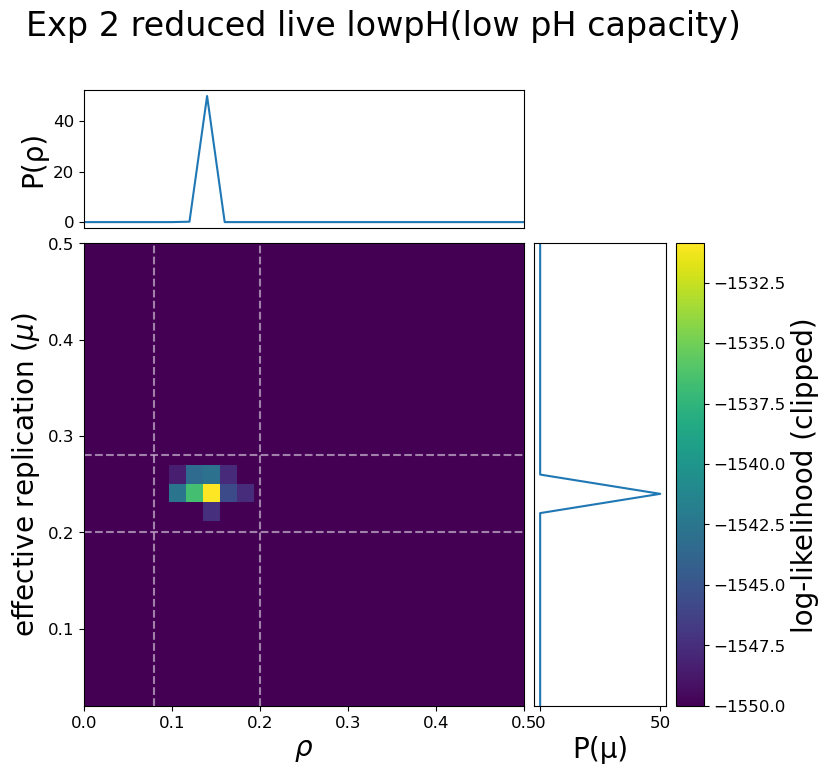

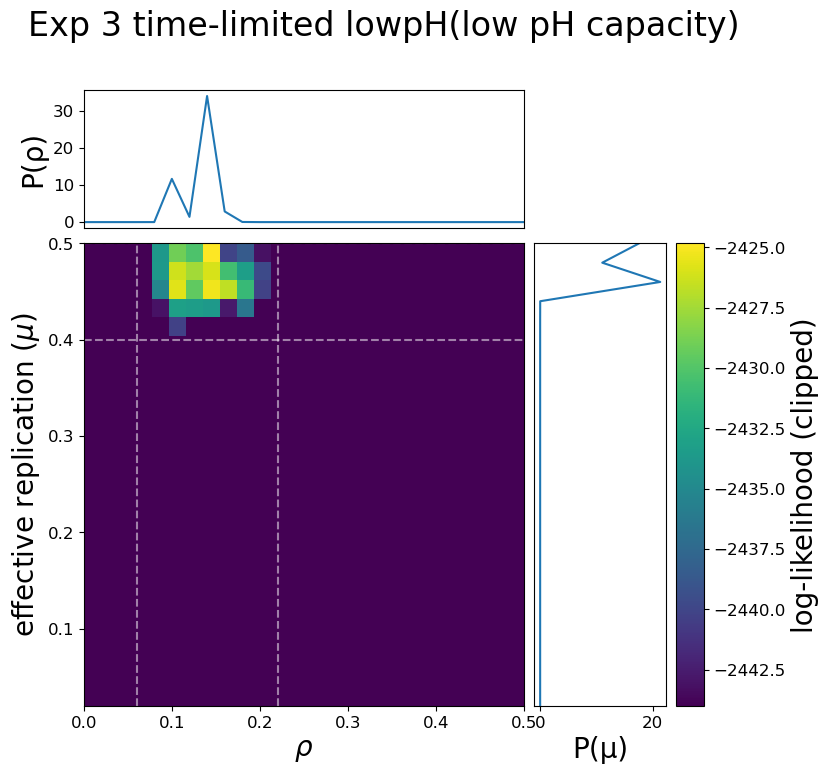

In [4]:

titles = ['Exp_2_reduced_live_lowpH', 'Exp_3_time-limited_lowpH']



for title in titles:
    input = f"grid_likelihood_outputs/{title}/grid_zomega_lowpH.csv"
    output = f"grid_likelihood_outputs/{title}/grid_zomega_lowpH.png"

    df = pd.read_csv(input)
    df = df[df["mu"]<=.5]
    df = df[df["rho"]<=.5]

    rhos = np.unique(df["rho"].values)
    mus = np.unique(df["mu"].values)

    sh = (mus.size, rhos.size)
    A = df["rho"].values.reshape(sh)
    M = df["mu"].values.reshape(sh)
    Z = df["loglike"].values.reshape(sh)

    Zeff = Z.clip(min = int(np.max(Z)-20))  # normalize to get log-probabilities
    Z_rho = logsumexp(Z, axis=0) - logsumexp(Z)
    Z_mu = logsumexp(Z, axis=1) - logsumexp(Z)

    r0, r1, c0, c1 = crop_by_threshold(Z, Zeff.min())

    # results.append({
    #     "title": title,
    #     "mu_low": mus[r0],
    #     "mu_high": mus[r1], 
    #     "rho_low": rhos[c0],
    #     "rho_high": rhos[c1],
    # })

    plt.rcParams.update({
        "font.size": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 20
    })

    P_rho = np.exp(Z_rho - np.log(rhos[1] - rhos[0]))
    P_mu    = np.exp(Z_mu - np.log(mus[1] - mus[0]))
    # --- layout ---


    # --- layout with dedicated colorbar column ---
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(
        2, 3,
        width_ratios=[4, 1.2, 0.25],   # extra column for colorbar
        height_ratios=[1.2, 4],
        hspace=0.05,
        wspace=0.05
    )

    ax_top    = fig.add_subplot(gs[0, 0])
    ax_joint  = fig.add_subplot(gs[1, 0])
    ax_right  = fig.add_subplot(gs[1, 1])
    ax_cbar   = fig.add_subplot(gs[1, 2])  # colorbar axis

    # --- joint heatmap ---
    # im = ax_joint.pcolormesh(
    #     alphas,
    #     mus,
    #     Zeff.T,
    #     shading="auto"
    # )
    
    im = ax_joint.imshow(
        Zeff,
        extent=[rhos.min(), rhos.max(), mus.min(), mus.max()],
        aspect="auto",
        origin="lower"
    )

    ax_joint.set_xlabel(r"$\rho$")
    ax_joint.set_ylabel(r"effective replication ($\mu$)")

    # --- colorbar in dedicated axis ---
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label("log-likelihood (clipped)")

    # --- top marginal ---
    ax_top.plot(rhos, P_rho)
    ax_top.set_xlim(ax_joint.get_xlim())
    ax_top.set_xticks([])
    ax_top.set_ylabel("P(ρ)")

    # --- right marginal ---
    ax_right.plot(P_mu, mus)
    ax_right.set_ylim(ax_joint.get_ylim())
    ax_right.set_yticks([])
    ax_right.set_xlabel("P(μ)")

    ax_joint.axvline(rhos[c0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axvline(rhos[c1], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r1], color="white", linestyle="--",alpha=0.5)

    plt.suptitle(title.replace("_", " ")+'(low pH capacity)')
    plt.tight_layout()

    plt.savefig(output, dpi=500)





In [5]:
titles_1d = ['Exp_1_live_lowpH','Exp_4_live_highpH']
df_1d = [pd.read_csv(f"grid_likelihood_outputs/{title}/grid_zomega.csv") for title in titles_1d]


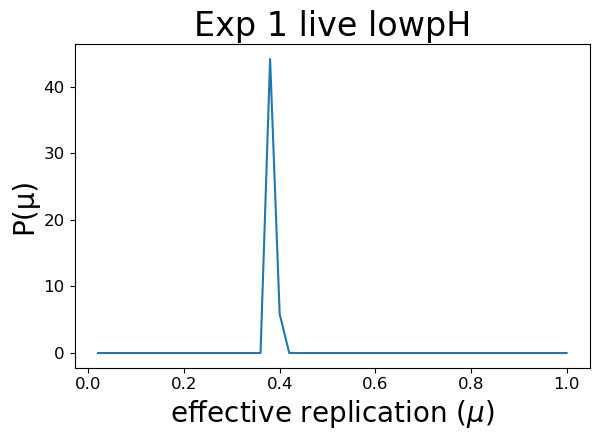

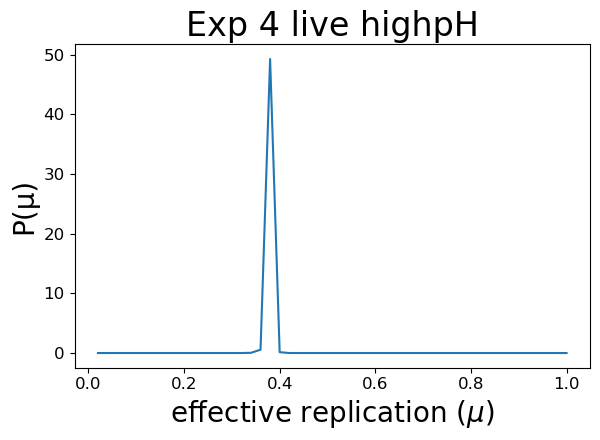

In [6]:
for title_1d in titles_1d:

    df_1d = pd.read_csv(f"grid_likelihood_outputs/{title_1d}/grid_zomega.csv")

    mu = df_1d["mu"].values
    loglike = df_1d["loglike"].values
    pmu = np.exp(loglike - logsumexp(loglike) - np.log(mu[1] - mu[0]))

    plt.plot(mu, pmu)
    plt.xlabel(r"effective replication ($\mu$)")
    plt.ylabel("P(μ)")
    plt.title(title_1d.replace("_", " "))
    plt.tight_layout()
    plt.savefig(f"grid_likelihood_outputs/{title_1d}/grid_zomega_1d.png", dpi=500)

    r0,r1 = crop_by_threshold(loglike, loglike.max() - 20)
    results.append({
        "title": title_1d,
        "mu_low": mu[r0],
        "mu_high": mu[r1],
    })
    plt.show()



In [7]:
df_cuts = pd.DataFrame(results)
df_cuts.to_csv("grid_likelihood_outputs/summary_cuts.csv", index=False)
#alphabetical order in title
df_cuts = df_cuts.sort_values("title")
df_cuts


,title,mu_low,mu_high,rho_low,rho_high
6,Exp_1_live_lowpH,0.38,0.42,NaN,NaN
0,Exp_2_reduced_live_lowpH,0.20,0.28,0.08,0.20
1,Exp_3_time-limited_lowpH,0.38,0.50,0.06,0.22
7,Exp_4_live_highpH,0.32,0.42,NaN,NaN
2,Exp_5_time-limited_highpH,0.30,0.40,0.08,0.20
3,Exp_6_BB_time-limited_highpH,0.22,0.36,0.02,0.14
4,Exp_7_low-salinity_time-limited,0.34,0.44,0.14,0.38
5,Exp_8_BB_low-salinity_time-limited,0.28,0.44,0.02,0.14
